# Process Flow: Full Model and Split by GROUP Changes

Loads `processflow_export.xes` and:

1. Discovers a **directly-follows graph** and a **Split Miner BPMN** for the full log.
2. Splits every trace at `GROUP` change boundaries (e.g. Aâ†’Aâ†’Bâ†’Bâ†’A yields three
   segments), groups the resulting segments by GROUP, and discovers a separate
   Split Miner BPMN for each group.

In [129]:
import pm4py
import pandas as pd
from pm4py.algo.discovery.split_miner import algorithm as split_miner
from pathlib import Path

In [130]:
LOG_PATH = Path("../../data/villach/processflow_export_2.xes")

log = pm4py.read_xes(str(LOG_PATH))
print(f"Traces: {log['case:concept:name'].nunique()}, Events: {len(log)}")
print(f"PROCESSAREAs: {sorted(log['PROCESSAREA'].unique())}")

parsing log, completed traces ::   0%|          | 0/46 [00:00<?, ?it/s]

Traces: 46, Events: 694
PROCESSAREAs: ['DDE3', 'LC3', 'PRE']


## Directly-Follows Graph (full log)

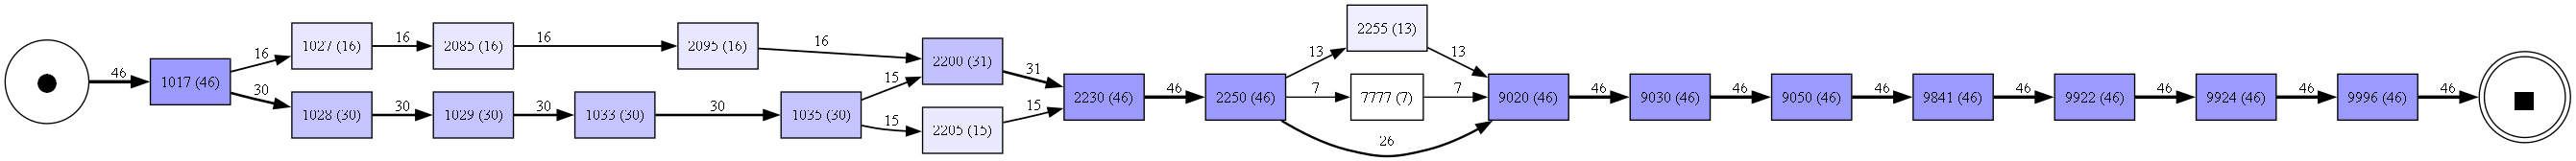

In [131]:
dfg, start, end = pm4py.discover_dfg(log)
pm4py.view_dfg(dfg, start, end)


## Split Miner BPMN (full log)

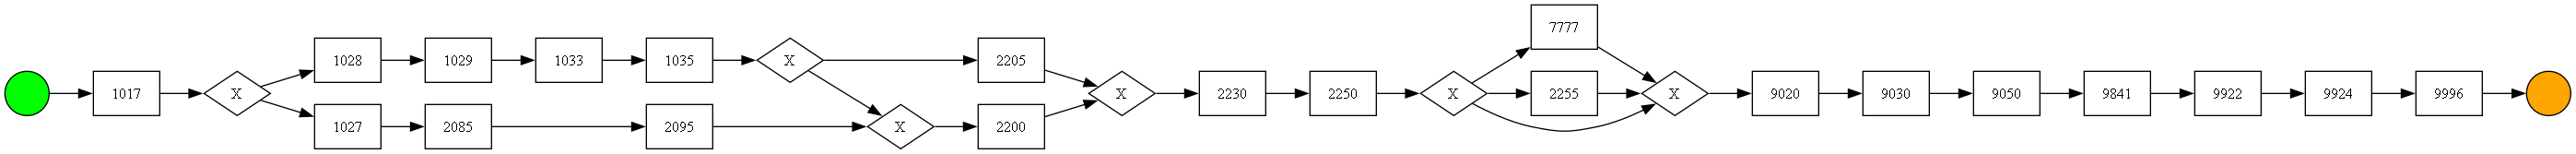

In [132]:
bpmn_full = split_miner.apply(log)
pm4py.view_bpmn(bpmn_full)


## Unify PROCESSAREA below threshold

For each OPERATION, find the dominant PROCESSAREA. If it accounts for
more than `THRESHOLD` of occurrences, rewrite minority values to match.

In [133]:
THRESHOLD = 0.9

changed = 0
for oper, grp in log.groupby("concept:name"):
    counts = grp["PROCESSAREA"].value_counts()
    dominant = counts.index[0]
    frac = counts.iloc[0] / counts.sum()
    if frac >= THRESHOLD:
        mask = log["concept:name"] == oper
        minority = log.loc[mask, "PROCESSAREA"] != dominant
        changed += minority.sum()
        log.loc[mask & minority, "PROCESSAREA"] = dominant

print(f"Unified {changed} events by threshold (threshold={THRESHOLD:.0%})")
print(f"PROCESSAREAs after: {sorted(log['PROCESSAREA'].unique())}")

Unified 3 events by threshold (threshold=90%)
PROCESSAREAs after: ['DDE3', 'LC3', 'PRE']


## Split traces at PROCESSAREA change boundaries

Walk each trace in `ROUTEOPERORDER` order.  Every time the `PROCESSAREA` value
changes, a new segment starts.  Each segment becomes an independent case
in a new event log, carrying the GROUP it belongs to.

In [134]:
rows = []
for case_id, trace in log.groupby("case:concept:name"):
    trace = trace.sort_values("ROUTEOPERORDER").reset_index(drop=True)
    areas = trace["PROCESSAREA"].tolist()

    # smooth out single-operation outliers: if an operation differs
    # from both neighbours (which agree), treat it as the neighbour
    # value for split-point detection
    smoothed = list(areas)
    op_names = trace["concept:name"].tolist()
    for i in range(1, len(smoothed) - 1):
        if smoothed[i] != smoothed[i-1] and smoothed[i] != smoothed[i+1] and smoothed[i-1] == smoothed[i+1]:
            print(f"Case {case_id}: smoothing {smoothed[i]} to {smoothed[i-1]} in operation {op_names[i]} (neighbors: {smoothed[i-1]}, {smoothed[i+1]})")
            smoothed[i] = smoothed[i-1]

    # a PROCESSAREA change is "stable" only if the new value persists
    # for at least one more consecutive step; transient blips are ignored.
    split_at = set()
    stable = smoothed[0] if smoothed else None
    for i in range(1, len(smoothed)):
        if smoothed[i] != stable and i + 1 < len(smoothed) and smoothed[i + 1] == smoothed[i]:
            split_at.add(i)
            stable = smoothed[i]

    seg_idx = 0
    for i, (_, ev) in enumerate(trace.iterrows()):
        if i in split_at:
            seg_idx += 1
        rows.append({
            "case:concept:name": f"{case_id}_seg{seg_idx}",
            "concept:name": ev["concept:name"],
            "time:timestamp": ev["time:timestamp"],
            "ROUTEOPERORDER": ev["ROUTEOPERORDER"],
            "PROCESSAREA": smoothed[i],
            "_orig_case": case_id,
            "_seg_idx": seg_idx,
        })

split_df = pd.DataFrame(rows)
n_segments = split_df["case:concept:name"].nunique()
print(f"Original traces: {log['case:concept:name'].nunique()}")
print(f"Segments after split: {n_segments}")
print(f"Segments per PROCESSAREA:")
for g, grp in split_df.groupby("PROCESSAREA"):
    print(f"  {g}: {grp['case:concept:name'].nunique()} segments, {len(grp)} events")

Case 12276866: smoothing DDE3 to PRE in operation 1035 (neighbors: PRE, PRE)
Case 13777645: smoothing DDE3 to PRE in operation 2095 (neighbors: PRE, PRE)
Case 5480738: smoothing DDE3 to PRE in operation 2095 (neighbors: PRE, PRE)
Case 5480739: smoothing DDE3 to PRE in operation 2095 (neighbors: PRE, PRE)
Case 5480740: smoothing DDE3 to PRE in operation 2095 (neighbors: PRE, PRE)
Case 5480742: smoothing DDE3 to PRE in operation 2095 (neighbors: PRE, PRE)
Case 5480745: smoothing DDE3 to PRE in operation 1035 (neighbors: PRE, PRE)
Case 5480746: smoothing DDE3 to PRE in operation 1035 (neighbors: PRE, PRE)
Case 5480747: smoothing DDE3 to PRE in operation 1035 (neighbors: PRE, PRE)
Case 5480748: smoothing DDE3 to PRE in operation 2095 (neighbors: PRE, PRE)
Case 5480749: smoothing DDE3 to PRE in operation 2095 (neighbors: PRE, PRE)
Case 5480750: smoothing DDE3 to PRE in operation 1035 (neighbors: PRE, PRE)
Case 5480751: smoothing DDE3 to PRE in operation 2095 (neighbors: PRE, PRE)
Case 54807

## Split Miner BPMN per PROCESSAREA

  Segments: 46, Events: 204


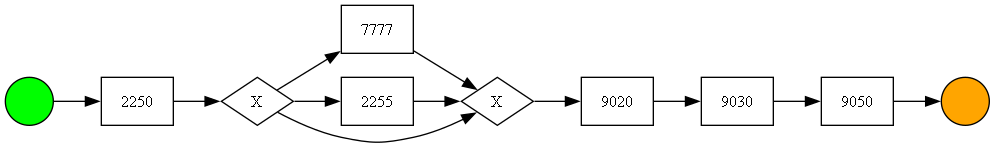

  Segments: 46, Events: 46


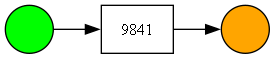

  Segments: 92, Events: 444


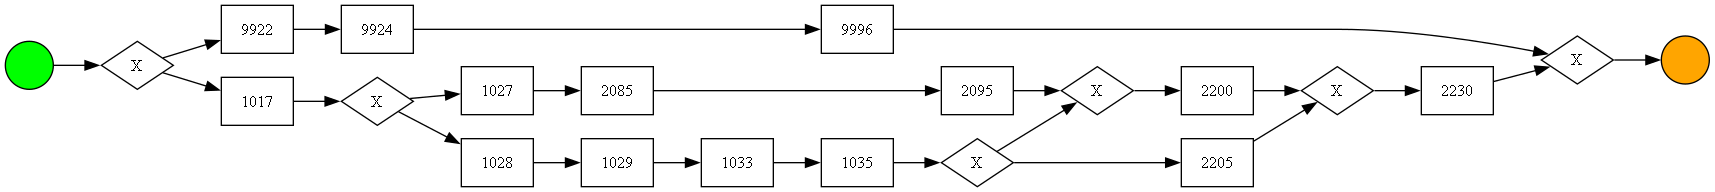

In [135]:
for group_name in sorted(split_df["PROCESSAREA"].unique()):

    sub_df = split_df[split_df["PROCESSAREA"] == group_name].copy()
    n_cases = sub_df["case:concept:name"].nunique()
    print(f"  Segments: {n_cases}, Events: {len(sub_df)}")

    bpmn = split_miner.apply(sub_df)
    pm4py.view_bpmn(bpmn)


## Execution variants per PROCESSAREA

In [137]:
for group_name in sorted(split_df["PROCESSAREA"].unique()):
    sub_df = split_df[split_df["PROCESSAREA"] == group_name].copy()
    variants = sub_df.sort_values("ROUTEOPERORDER").groupby("case:concept:name")["concept:name"].apply(tuple).value_counts().sort_values(ascending=False)
    for seq, count in variants.items():
        print(f"  [{count:3d}x] {' -> '.join(seq)}")


  [ 26x] 2250 -> 9020 -> 9030 -> 9050
  [ 13x] 2250 -> 2255 -> 9020 -> 9030 -> 9050
  [  7x] 2250 -> 7777 -> 9020 -> 9030 -> 9050
  [ 46x] 9841
  [ 46x] 9922 -> 9924 -> 9996
  [ 16x] 1017 -> 1027 -> 2085 -> 2095 -> 2200 -> 2230
  [ 15x] 1017 -> 1028 -> 1029 -> 1033 -> 1035 -> 2200 -> 2230
  [ 15x] 1017 -> 1028 -> 1029 -> 1033 -> 1035 -> 2205 -> 2230
